In [1]:
pip install yfinance

In [ ]:
!pip install tensorflow

In [ ]:
import numpy as np
import yfinance as yf
from datetime import datetime, timedelta
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os


In [ ]:
# 获取昨天的日期
end_date = datetime.today() - timedelta(days=1)
start_date = end_date - timedelta(days=365 * 5)

# 格式化为字符串形式（yfinance需要）
start_str = start_date.strftime('%Y-%m-%d')
end_str = end_date.strftime('%Y-%m-%d')

# 下载江西铜业的股票数据
ticker = "601319.SS"
data = yf.download(ticker, start=start_str, end=end_str)

# 保存为CSV文件
data.to_csv('recent_stock_prices.csv')
print(f"数据已保存到 recent_stock_prices.csv（从 {start_str} 到 {end_str}）")

import pandas as pd

pf = pd.read_csv("recent_stock_prices.csv")
print(pf.head())

# 加载原始 CSV 文件
try:
    data = pd.read_csv('recent_stock_prices.csv')
    print("CSV 数据预览：")
    print(data.head())
except pd.errors.EmptyDataError:
    print("CSV 文件为空，请检查数据来源或重新下载。")
except FileNotFoundError:
    print("文件不存在，请确认文件路径是否正确。")


/tmp/ipython-input-1621007160.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_str, end=end_str)
[*********************100%***********************]  1 of 1 completed


数据已保存到 recent_stock_prices.csv（从 2020-08-26 到 2025-08-25）
        Price              Close                High                Low  \
0      Ticker          601319.SS           601319.SS          601319.SS   
1        Date                NaN                 NaN                NaN   
2  2020-08-26  6.222318172454834  6.3526740857460995  6.213627999243429   
3  2020-08-27  6.248389720916748   6.283151243655336  6.178866675439572   
4  2020-08-28  6.370054721832275   6.378745309263541  6.196247117107117   

                Open     Volume  
0          601319.SS  601319.SS  
1                NaN        NaN  
2  6.326603151721861   58893344  
3  6.222318371667788   39077335  
4  6.213627877579633   61961226  
CSV 数据预览：
        Price              Close                High                Low  \
0      Ticker          601319.SS           601319.SS          601319.SS   
1        Date                NaN                 NaN                NaN   
2  2020-08-26  6.222318172454834  6.3526740857460995

In [ ]:

# 读取原始 CSV
df = pd.read_csv('recent_stock_prices.csv')

# 重命名列并删除前两行
df.columns = ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
df = df.iloc[2:].reset_index(drop=True)

# 转换数据类型
df[['Close', 'High', 'Low', 'Open', 'Volume']] = df[['Close', 'High', 'Low', 'Open', 'Volume']].astype(float)

# 日期格式转换
df['Date'] = pd.to_datetime(df['Date'])

df.to_csv('cleaned_stock_data.csv', index=False)
print(df.head())

        Date     Close      High       Low      Open      Volume
0 2020-08-26  6.222318  6.352674  6.213628  6.326603  58893344.0
1 2020-08-27  6.248390  6.283151  6.178867  6.222318  39077335.0
2 2020-08-28  6.370055  6.378745  6.196247  6.213628  61961226.0
3 2020-08-31  6.274461  6.422197  6.265771  6.396127  63782785.0
4 2020-09-01  6.300532  6.300532  6.222319  6.257080  38351078.0


In [ ]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 设置绘图风格（使用 Matplotlib 自带的样式）
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-darkgrid')


In [ ]:
# 设置窗口大小和预测偏移
window_size = 50         # 用过去 50 天的数据预测
target_shift = 1         # 预测未来第 1 天的收盘价


In [ ]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [ ]:
# 加载你的数据（假设 CSV 文件中包含 Date 和 Close 列）
df = pd.read_csv('cleaned_stock_data.csv', parse_dates=['Date'])
df.sort_values('Date', inplace=True)

# 计算 MACD 和信号线
def compute_macd(df, fast=12, slow=26, signal=9):
    df['EMA_fast'] = df['Close'].ewm(span=fast, adjust=False).mean()
    df['EMA_slow'] = df['Close'].ewm(span=slow, adjust=False).mean()
    df['MACD'] = df['EMA_fast'] - df['EMA_slow']
    df['MACD_signal'] = df['MACD'].ewm(span=signal, adjust=False).mean()
    return df

# 计算 RSI 指标
def compute_rsi(df, period=14):
    delta = df['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))
    return df

# 添加技术指标
def add_technical_indicators(df):
    df = compute_macd(df)
    df = compute_rsi(df)
    df.dropna(inplace=True)
    return df

# 应用技术指标
df = add_technical_indicators(df)


In [ ]:
# 添加周期性时间特征（例如：星期几、月份）
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 周一=0，周日=6
df['Month'] = df['Date'].dt.month

# 转为周期性编码（sin/cos）
df['Day_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['Day_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])


NameError: name 'features' is not defined

In [ ]:
X, y = [], []
for i in range(window_size, len(scaled_data) - target_shift):
    X.append(scaled_data[i - window_size:i])
    y.append(scaled_data[i + target_shift][0])  # 预测收盘价

NameError: name 'scaled_data' is not defined

In [ ]:
# 设置窗口大小和预测偏移
window_size = 50         # 用过去 50 天的数据预测
target_shift = 1         # 预测未来第 1 天的收盘价

# 选择用于训练的特征（你已经更新过了）
features = ['Close', 'MACD', 'MACD_signal', 'RSI', 'Day_sin', 'Day_cos', 'Month_sin', 'Month_cos']

# 归一化处理
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])


# 构建训练数据集
X, y = [], []
for i in range(window_size, len(scaled_data) - target_shift):
    X.append(scaled_data[i - window_size:i])
    y.append(scaled_data[i + target_shift][0])  # 预测收盘价

X, y = np.array(X), np.array(y)

# 划分训练集和验证集
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, shuffle=False)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 构建模型函数
def build_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(32))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# 构建模型（确保 X_train 已定义）
model = build_lstm_model((X_train.shape[1], X_train.shape[2]))

# 回调函数（可选）
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True)

# 模型训练
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, checkpoint],
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
25/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2212

29/29 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 0.2053 - val_loss: 1.8442
Epoch 2/100
26/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0338

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0335 - val_loss: 1.8106
Epoch 3/100
28/29 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0264

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0264 - val_loss: 1.6092
Epoch 4/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0255 - val_loss: 1.6384
Epoch 5/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0223 - val_loss: 1.6339
Epoch 6/100
24/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0199

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0202 - val_loss: 1.5994
Epoch 7/100
24/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0209

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0209 - val_loss: 1.5853
Epoch 8/100
24/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0216

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0214 - val_loss: 1.4553
Epoch 9/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0210 - val_loss: 1.5409
Epoch 10/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0200 - val_loss: 1.5373
Epoch 11/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0168 - val_loss: 1.4849
Epoch 12/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0184 - val_loss: 1.5299
Epoch 13/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0173 - val_loss: 1.5386
Epoch 14/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0173 - val_loss: 1.5321
Epoch 15/100
23/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0149

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0150 - val_loss: 1.4254
Epoch 16/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0144 - val_loss: 1.4364
Epoch 17/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0138 - val_loss: 1.4410
Epoch 18/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0152 - val_loss: 1.4496
Epoch 19/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0142 - val_loss: 1.5160
Epoch 20/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0131 - val_loss: 1.5576
Epoch 21/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0169 - val_loss: 1.5141
Epoch 22/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0136 - val_loss: 1.5369
Epoch 23/100
23/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0137

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0135 - val_loss: 1.3609
Epoch 24/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0139 - val_loss: 1.4304
Epoch 25/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0123 - val_loss: 1.4882
Epoch 26/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0130 - val_loss: 1.5221
Epoch 27/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0123 - val_loss: 1.4425
Epoch 28/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0126 - val_loss: 1.4893
Epoch 29/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0125 - val_loss: 1.6409
Epoch 30/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0106 - val_loss: 1.5545
Epoch 31/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0131 - val_loss: 1.5226
Epoch 32/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0122 - val_loss: 1.4028
Epoch 33/100
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0132 - val_loss: 1.6206


In [ ]:
# 模型预测
y_pred = model.predict(X_val)

# 反归一化（只对 'Close' 一列）
y_val_rescaled = scaler.inverse_transform(
    np.concatenate([y_val.reshape(-1, 1), np.zeros((len(y_val), len(features)-1))], axis=1)
)[:, 0]

y_pred_rescaled = scaler.inverse_transform(
    np.concatenate([y_pred, np.zeros((len(y_pred), len(features)-1))], axis=1)
)[:, 0]


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) Liberatio

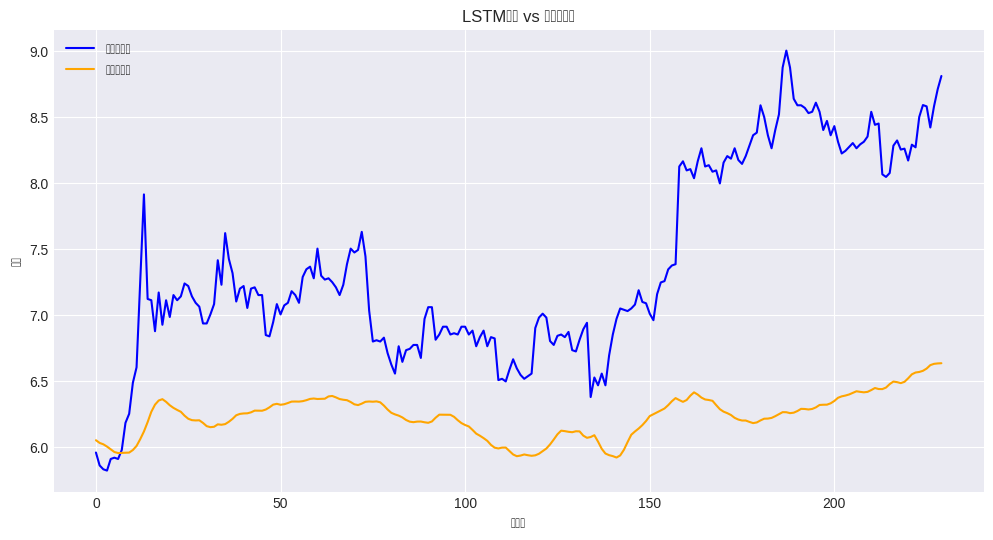

In [ ]:
import matplotlib.pyplot as plt

def plot_predictions(y_true, y_pred, title='LSTM预测 vs 实际收盘价'):
    plt.figure(figsize=(12, 6))
    plt.plot(y_true, label='实际收盘价', color='blue')
    plt.plot(y_pred, label='预测收盘价', color='orange')
    plt.title(title)
    plt.xlabel('时间步')
    plt.ylabel('价格')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_predictions(y_val_rescaled, y_pred_rescaled)


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(y_val_rescaled, y_pred_rescaled))
mae = mean_absolute_error(y_val_rescaled, y_pred_rescaled)

print(f'RMSE: {rmse:.2f}, MAE: {mae:.2f}')


RMSE: 1.30, MAE: 1.14


In [ ]:
last_sequence = scaled_data[-60:]  # 假设 lookback=60
future_preds = []

for _ in range(30):  # 预测未来30天
    input_seq = last_sequence.reshape(1, 60, len(features))
    pred = model.predict(input_seq)[0, 0]
    future_preds.append(pred)

    # 更新序列
    new_row = np.zeros((1, len(features)))
    new_row[0, 0] = pred  # 只填 'Close'，其他特征可用平均值或前值
    last_sequence = np.vstack([last_sequence[1:], new_row])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━

In [ ]:
future_preds_array = np.array(future_preds).reshape(-1, 1)

# 构造虚拟特征矩阵用于反归一化（只填 'Close'）
dummy = np.zeros((len(future_preds_array), len(features)-1))
future_rescaled = scaler.inverse_transform(np.hstack([future_preds_array, dummy]))[:, 0]


In [ ]:
last_date = df['Date'].iloc[-1] # Get the last date from the 'Date' column
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)

/tmp/ipython-input-3241551733.py:14: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3241551733.py:14: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3241551733.py:14: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3241551733.py:14: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3241551733.py:14: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3241551733.py:14: UserWarning: Glyph 26469 (\N{CJK UNIFIED IDEOGRAPH-6765}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-3241551733.py:14: UserWarning: Glyph 22825 (\N{CJK UNIFIE

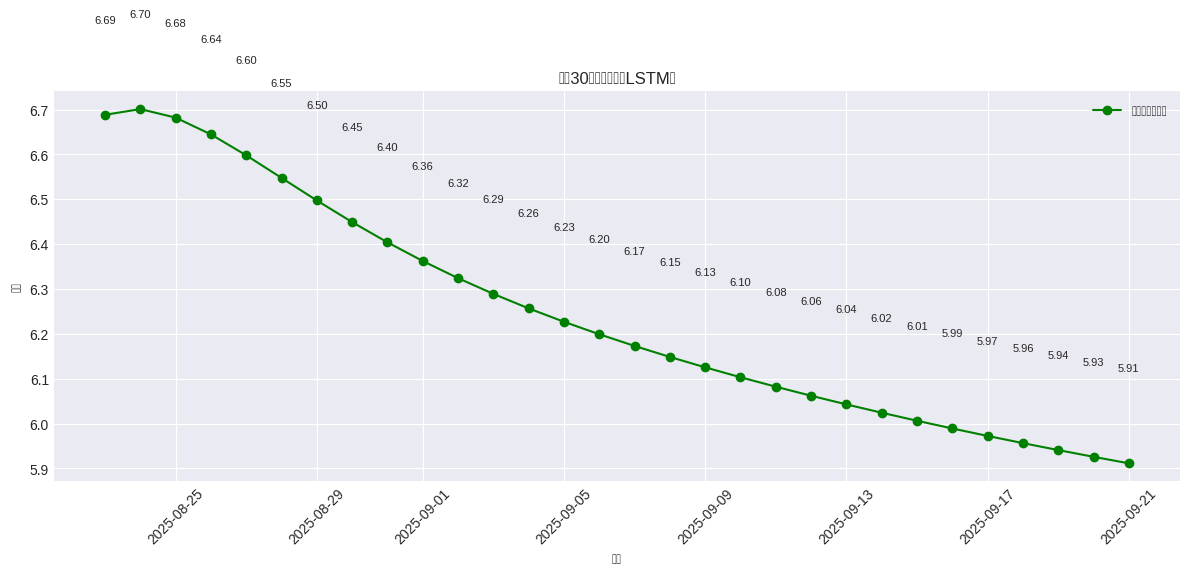

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(future_dates, future_rescaled, label='未来预测收盘价', color='green', marker='o')  # 加上圆点标记
plt.title('未来30天股价预测（LSTM）')
plt.xlabel('日期')
plt.ylabel('价格')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)

# 添加价格标注
for x, y in zip(future_dates, future_rescaled):
    plt.text(x, y + 0.2, f'{y:.2f}', ha='center', va='bottom', fontsize=8, rotation=0)

plt.tight_layout()
plt.show()


/tmp/ipython-input-1989921405.py:26: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1989921405.py:26: UserWarning: Glyph 26399 (\N{CJK UNIFIED IDEOGRAPH-671F}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1989921405.py:26: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1989921405.py:26: UserWarning: Glyph 26684 (\N{CJK UNIFIED IDEOGRAPH-683C}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1989921405.py:26: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1989921405.py:26: UserWarning: Glyph 26410 (\N{CJK UNIFIED IDEOGRAPH-672A}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipython-input-1989921405.py:26: UserWarning: Glyph 26469 (\N{CJK UNIFI

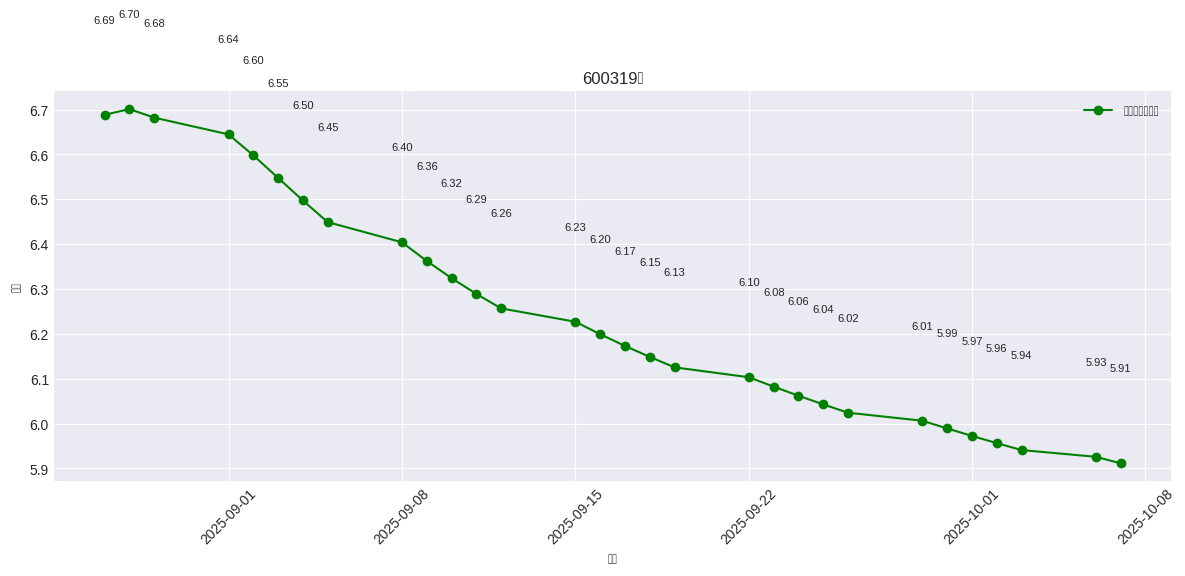

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# 1️⃣ 生成未来的交易日（跳过周末）
start_date = datetime.today().date() + timedelta(days=1) # Start from tomorrow's date
future_dates = pd.bdate_range(start=start_date, periods=30)

# 2️⃣ 假设你已经有预测值 future_rescaled（长度为30）
# future_rescaled = model.predict(...) 或其他方式得到的预测结果

# 3️⃣ 绘图
plt.figure(figsize=(12, 6))
plt.plot(future_dates, future_rescaled, label='未来预测收盘价', color='green', marker='o')
plt.title('600319）')
plt.xlabel('日期')
plt.ylabel('价格')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)

# 添加价格标注
for x, y in zip(future_dates, future_rescaled):
    plt.text(x, y + 0.2, f'{y:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


挂载成功后，你可以使用以下代码将文件复制到你的 Google Drive。请将 `'your_folder_in_drive'` 替换为你想要保存到的 Drive 中的文件夹名称，将 `'your_file_name.csv'` 或 `'your_model_name.h5'` 替换为你想要保存的文件名。

In [ ]:
import os
import shutil

# 指定要保存的模型文件名（原始文件名）
original_model_file = 'best_model.h5'

# 指定保存到 Google Drive 的新文件名
new_model_name = 'my_stock_601319n_model.h5' # 您可以改成您想记的名字

# 指定 Google Drive 中保存文件的目标文件夹
drive_folder = '/content/drive/My Drive/Your Stock Models' # 请将 'Your Stock Models' 替换为您想要创建或使用的文件夹名称

# 如果目标文件夹不存在，则创建它
if not os.path.exists(drive_folder):
    os.makedirs(drive_folder)
    print(f"创建了新的文件夹: {drive_folder}")

# 构建目标文件路径 for the model
destination_path_model = os.path.join(drive_folder, new_model_name)

# 将模型文件复制到 Google Drive 并改名
try:
    shutil.copy(original_model_file, destination_path_model)
    print(f"模型已保存并改名为 '{new_model_name}' 到 '{drive_folder}'")
except FileNotFoundError:
    print(f"错误：文件 '{original_model_file}' 不存在。")

# Specify the original and new names for the CSV file
original_csv_file = 'cleaned_stock_data.csv'
new_csv_name = 'your_file_601319.csv'

# Build the destination path for the CSV file
destination_path_csv = os.path.join(drive_folder, new_csv_name)

# Copy the CSV file to Google Drive and rename it
try:
    shutil.copy(original_csv_file, destination_path_csv)
    print(f"CSV 文件已保存并改名为 '{new_csv_name}' 到 '{drive_folder}'")
except FileNotFoundError:
    print(f"错误：文件 '{original_csv_file}' 不存在。")

模型已保存并改名为 'my_stock_601319n_model.h5' 到 '/content/drive/My Drive/Your Stock Models'
CSV 文件已保存并改名为 'your_file_601319.csv' 到 '/content/drive/My Drive/Your Stock Models'
